In [5]:
import numpy as np
from votekit.cvr_loaders import load_scottish
import matplotlib.pyplot as plt
from votekit import PreferenceProfile, PreferenceInterval
from votekit import Ballot
import votekit.ballot_generator as bg
from votekit.elections import STV, fractional_transfer
from votekit.plots import plot_summary_stats
import math
from fractions import Fraction
import itertools as it
import pickle

# used to import local files
import sys  
sys.path.insert(1, './')

from swap_distance import *

from collections import Counter
from scipy.stats import wasserstein_distance, kstest
import pandas as pd

plt.rcParams['text.usetex'] = True
SMALL_SIZE = 16
MEDIUM_SIZE = 20
BIGGER_SIZE = 24

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

In [6]:
b_bloc_parties = ['Scottish National Party (SNP)', 'Green (Gr)']
file_names = {("fife", 2022, 21): "../election_data/fife_2022_ward21.csv",
              ("aberdeen", 2017, 12) : "../election_data/aberdeen_2017_ward12.csv",
              ("aberdeen", 2022, 12): "../election_data/aberdeen_2022_ward12.csv",
              ("angus", 2012, 8): "../election_data/angus_2012_ward8.csv",
              ("falkirk", 2017, 6): "../election_data/falkirk_2017_ward6.csv",
              ("clackmannanshire", 2012, 2): "../election_data/clackmannanshire_2012_ward2.csv",
              ("renfrewshire", 2017, 1): "../election_data/renfrewshire_2017_ward1.csv",
              ("glasgow", 2012, 16): "../election_data/glasgow_2012_ward16.csv",
              ("north-ayrshire", 2022, 1): "../election_data/north_ayrshire_2022_north_coast.csv"
              }


new_models = ["CS-C", "CS-W", "n-BT", "n-PL", "s-BT", "s-PL"]
old_models = ["SB", "IC", "IAC"]
scottish_color = ["#1560BD"]
model_to_color = {'CS-C': '#D2691E', 'CS-W': '#E32636', 'n-BT': '#8B008B', 'n-PL': '#FFB7C5', 's-BT': '#FFBF00', 's-PL': '#8DB600',"SB":"#09FCEE", "IC":"#1A7601",
                      "IAC":"#929292" }

In [8]:
def bubble_plot_integer(ax, data, labels, colors, title, bloc_order, marker =".", size = 1000):
    # create figure
    # fig, ax = plt.subplots() #plt.figure()
    
    x_max = int(max(max(vector) for vector in data))
    bin_min = 0
    bin_max = x_max
    bins = np.arange(bin_min-.5, bin_max+1.5, 1)
    
    for j, vector in enumerate(data):
        x = [i for i in range(x_max+1)] # x=0,...,x_max
        y = [j+1]*len(x) # put each vector at a different height
        
        bin_heights, bin_edges = np.histogram(vector, bins = bins,density=True)
        circle_areas = [size*bin_heights[i] for i in range(x_max+1)]
        ax.scatter(x, y, s=circle_areas, alpha=1, color = colors[j], label = None, edgecolors='black', marker=marker)

    # Add labels and title
    ax.set_xlabel(f'Distance to solid ballot ({bloc_order})')
    ax.set_xticks([i for i in range(x_max+1)])
    ax.tick_params(axis='x', labelrotation=90)
    ax.set_yticks([i+1 for i in range(len(data))], labels)
    ax.set_xlim((-2, x_max+2))
    ax.set_ylim((0.5, len(data)+.5))
    ax.set_title(title)
    
    return ax

# 1 bloc bubble plots

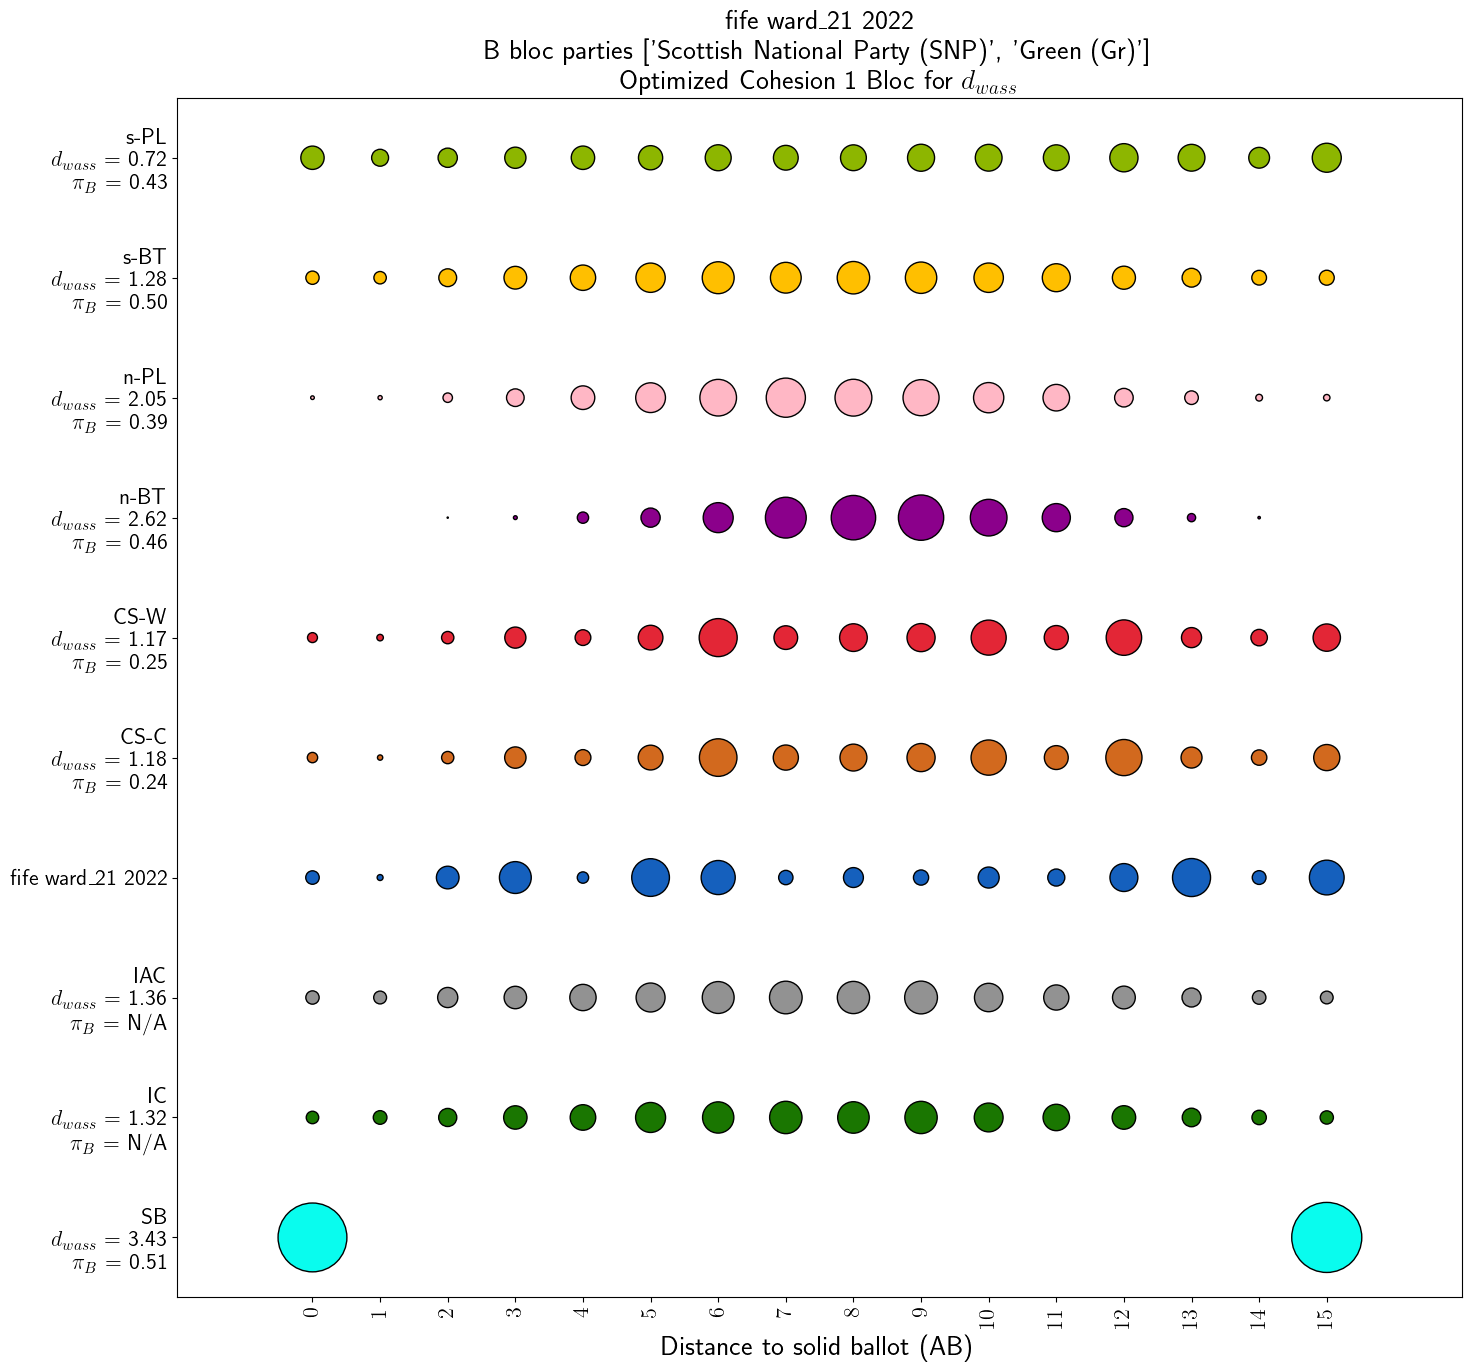

<Figure size 640x480 with 0 Axes>

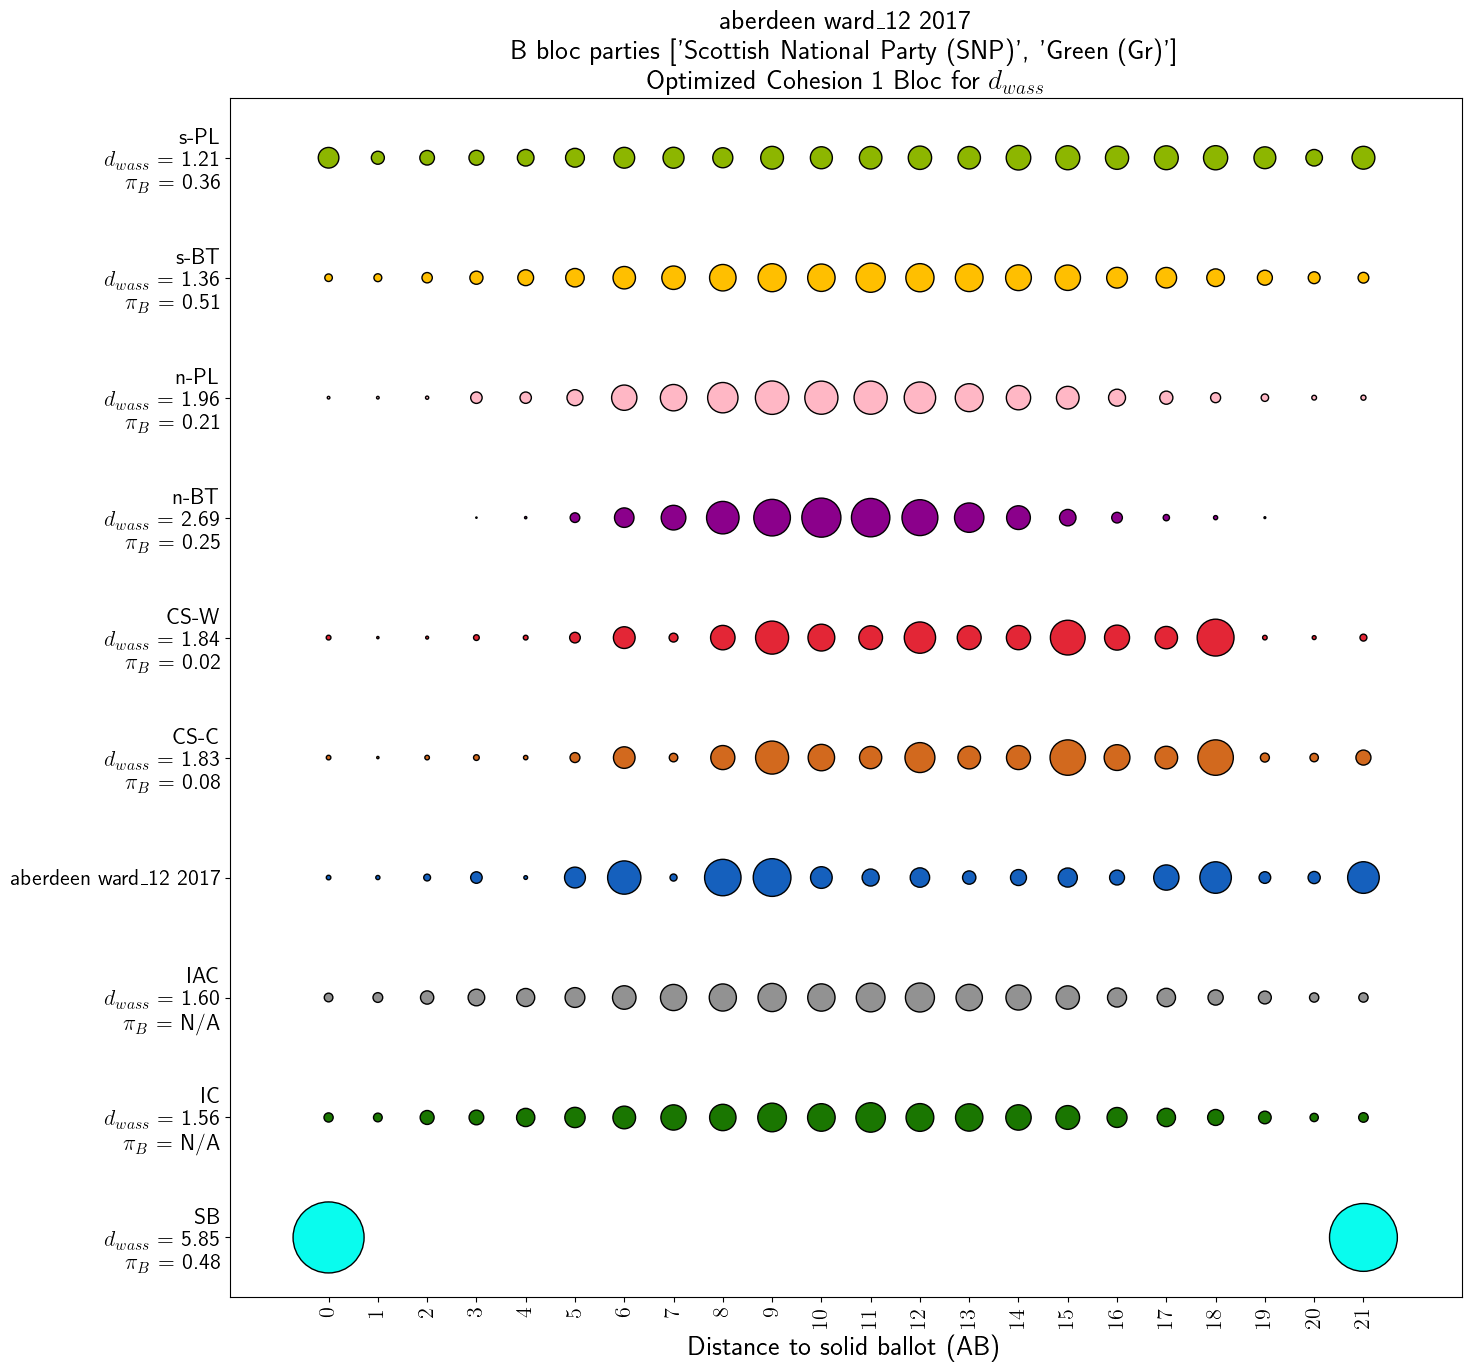

<Figure size 640x480 with 0 Axes>

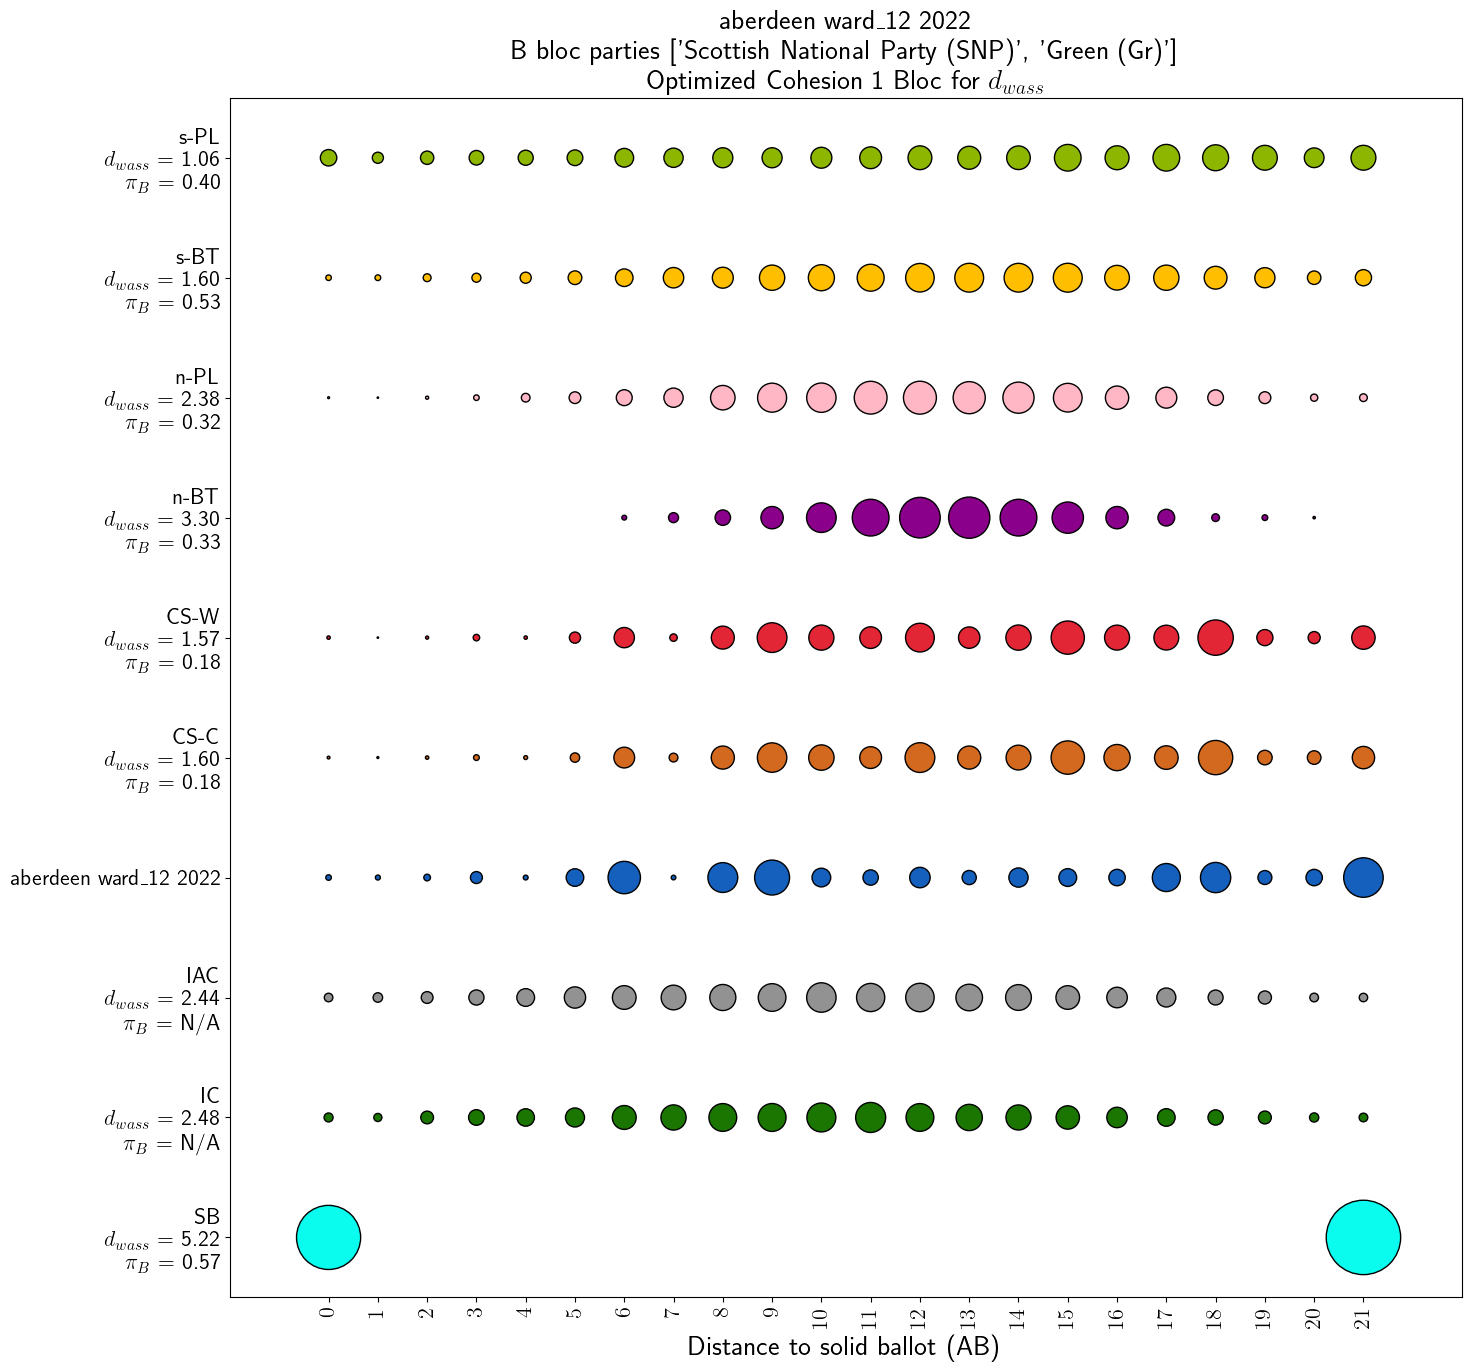

<Figure size 640x480 with 0 Axes>

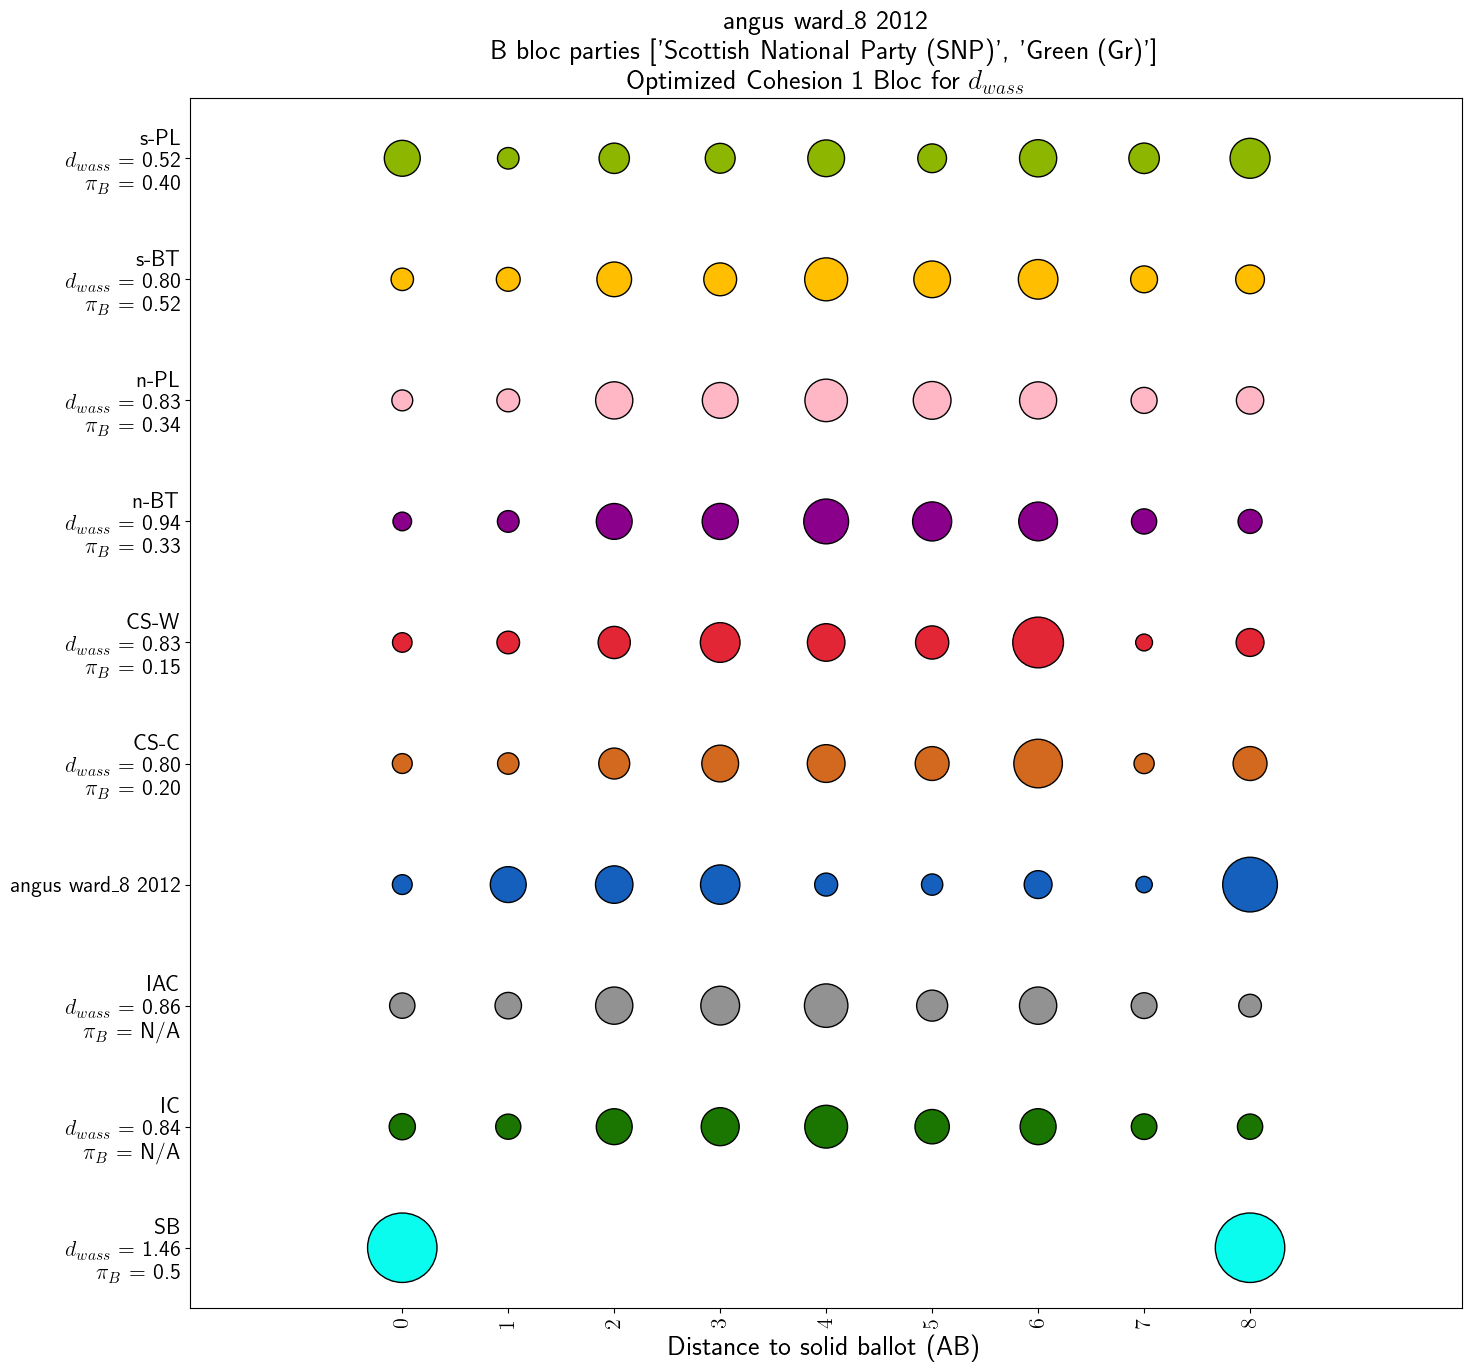

<Figure size 640x480 with 0 Axes>

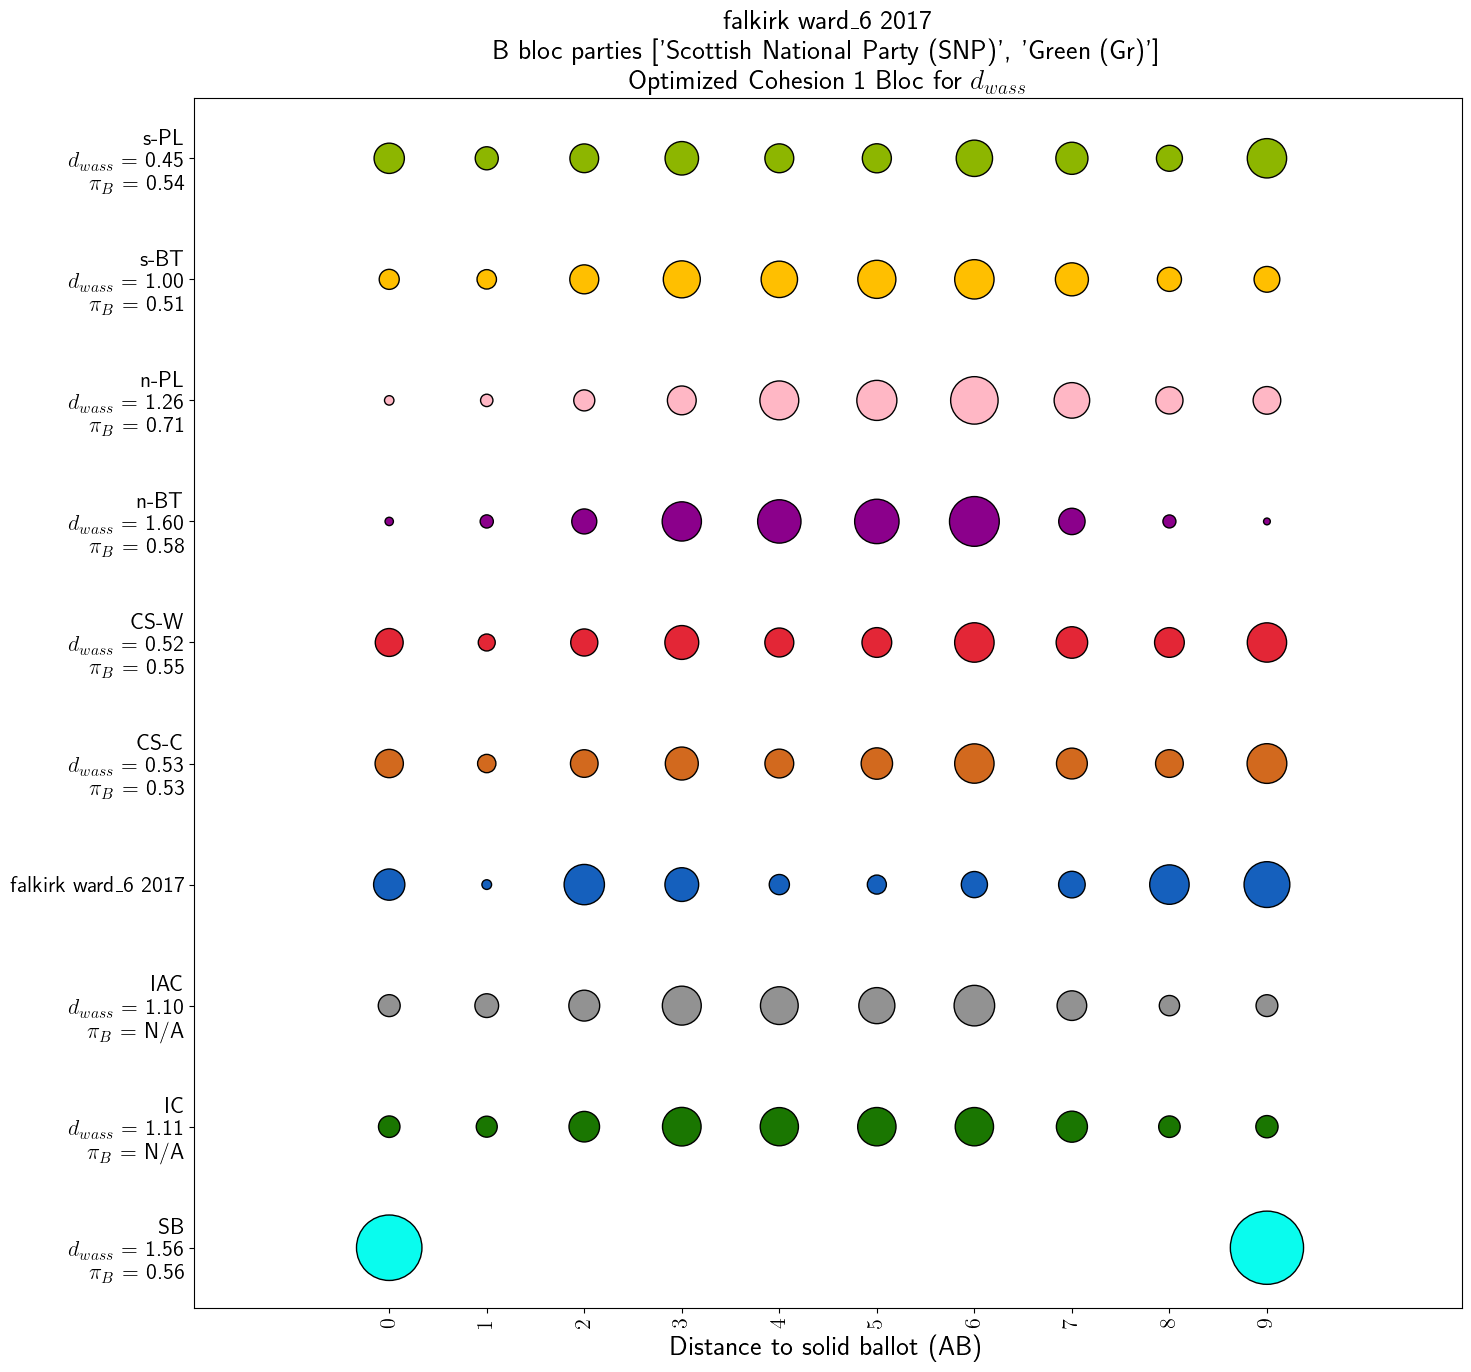

<Figure size 640x480 with 0 Axes>

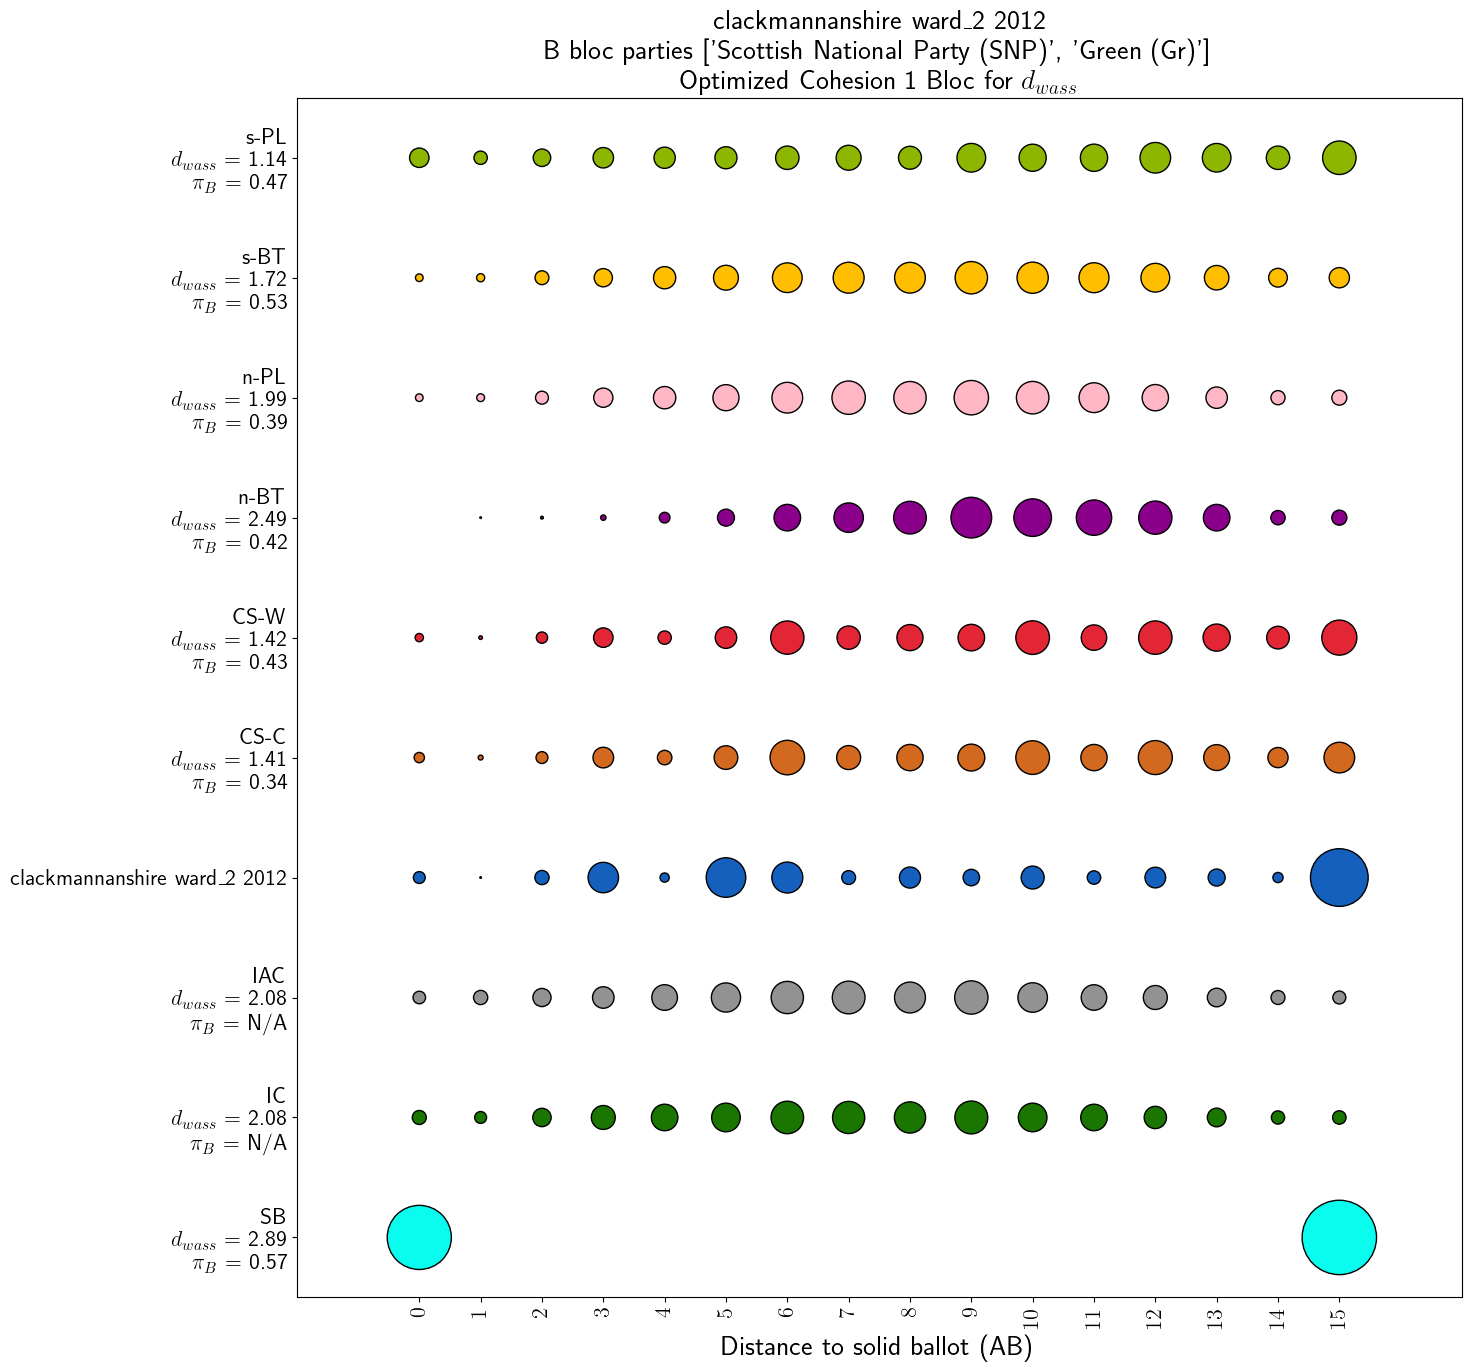

<Figure size 640x480 with 0 Axes>

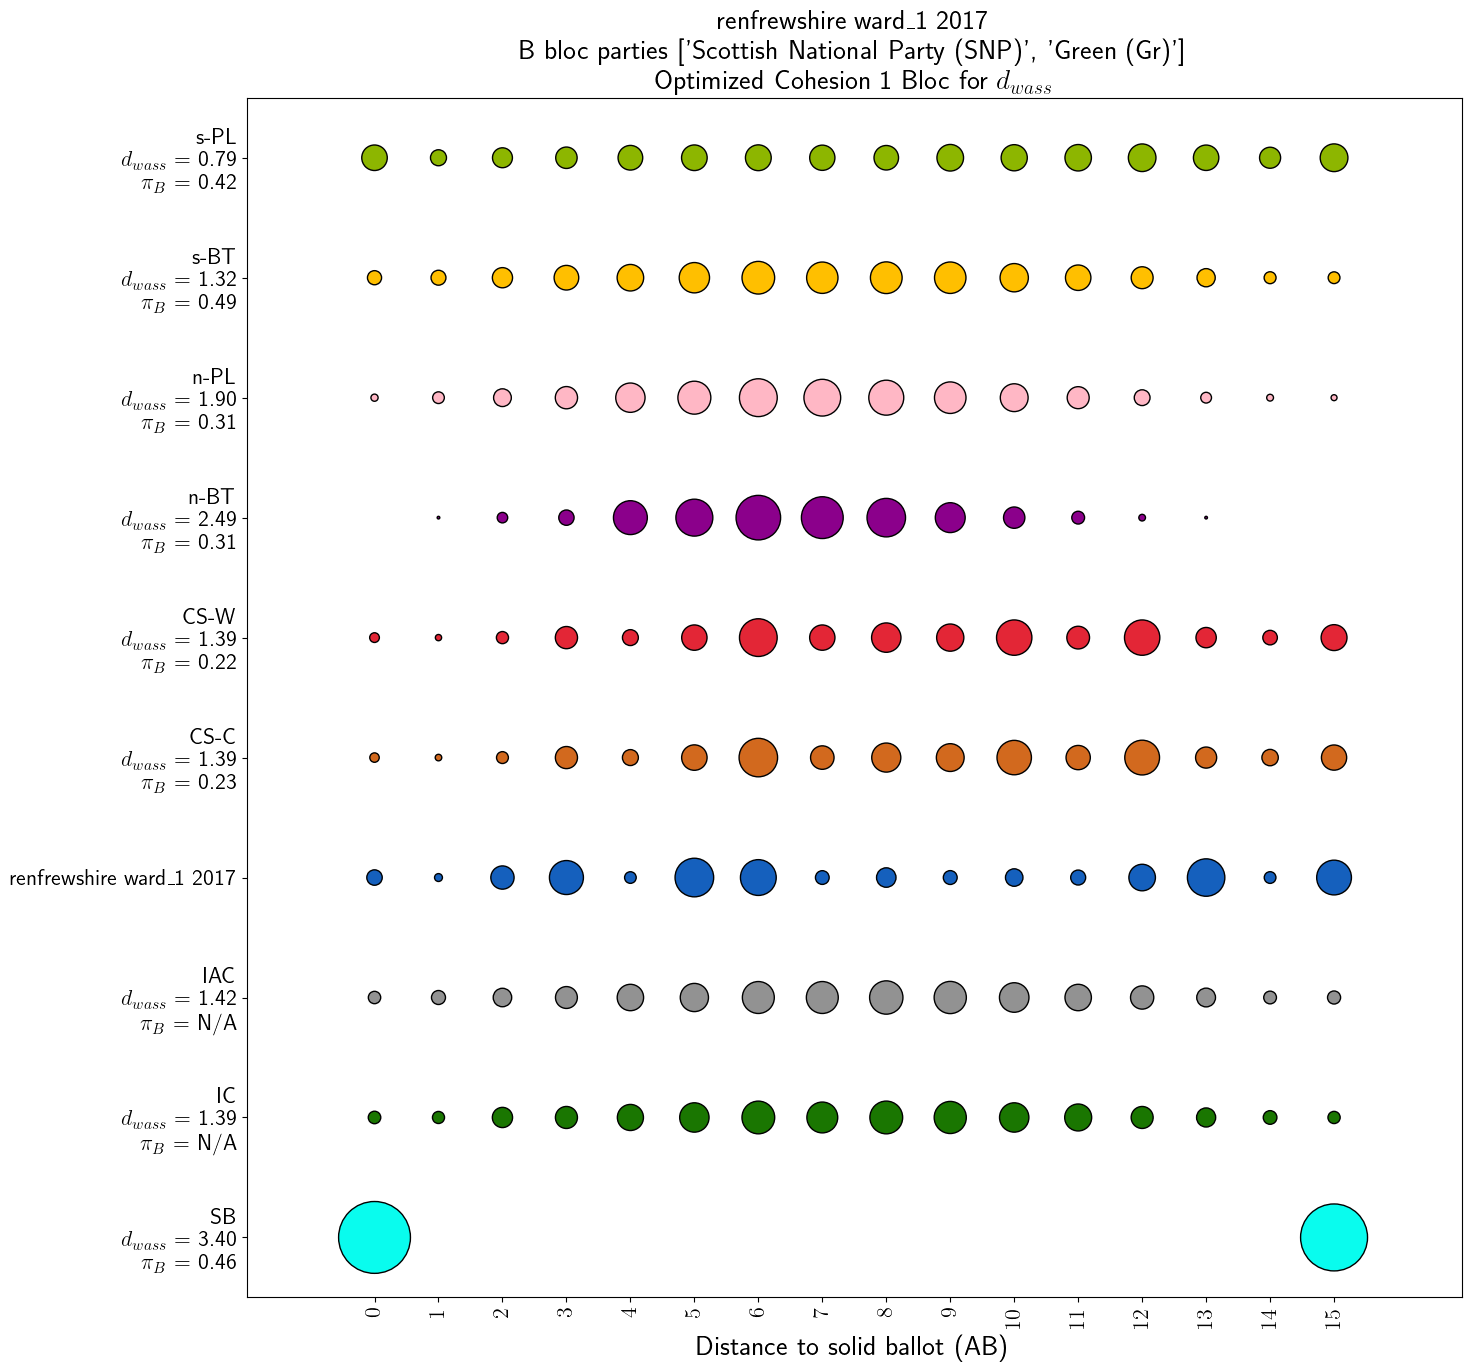

<Figure size 640x480 with 0 Axes>

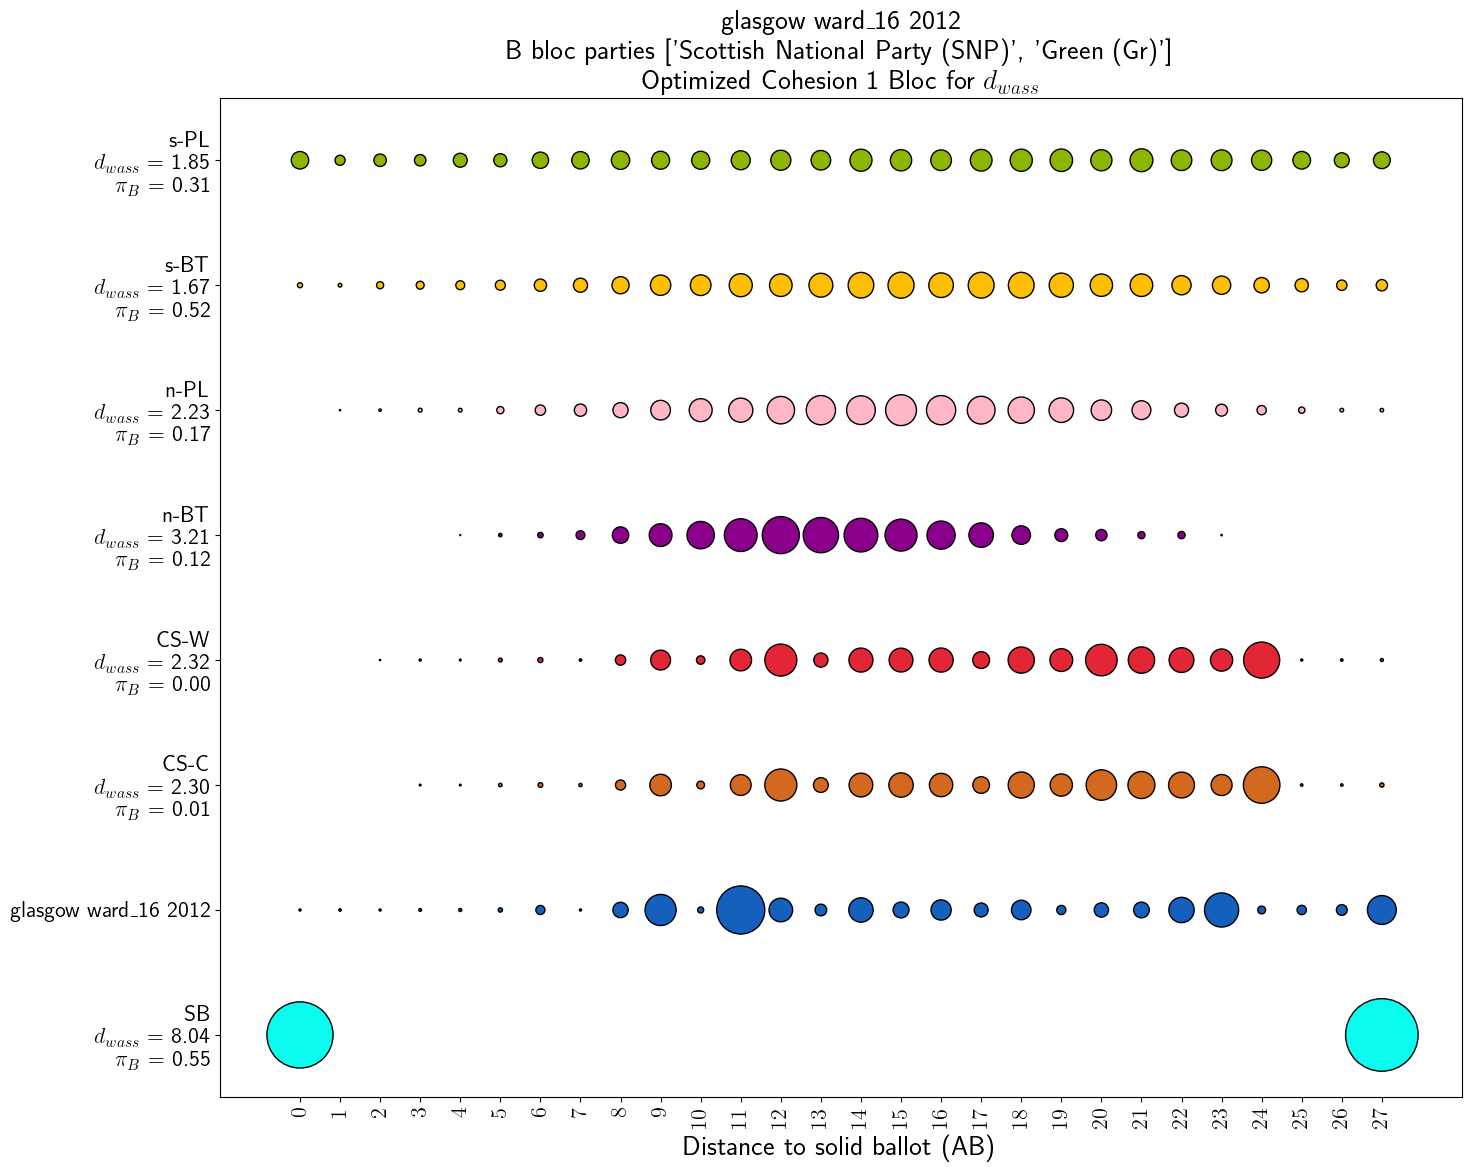

<Figure size 640x480 with 0 Axes>

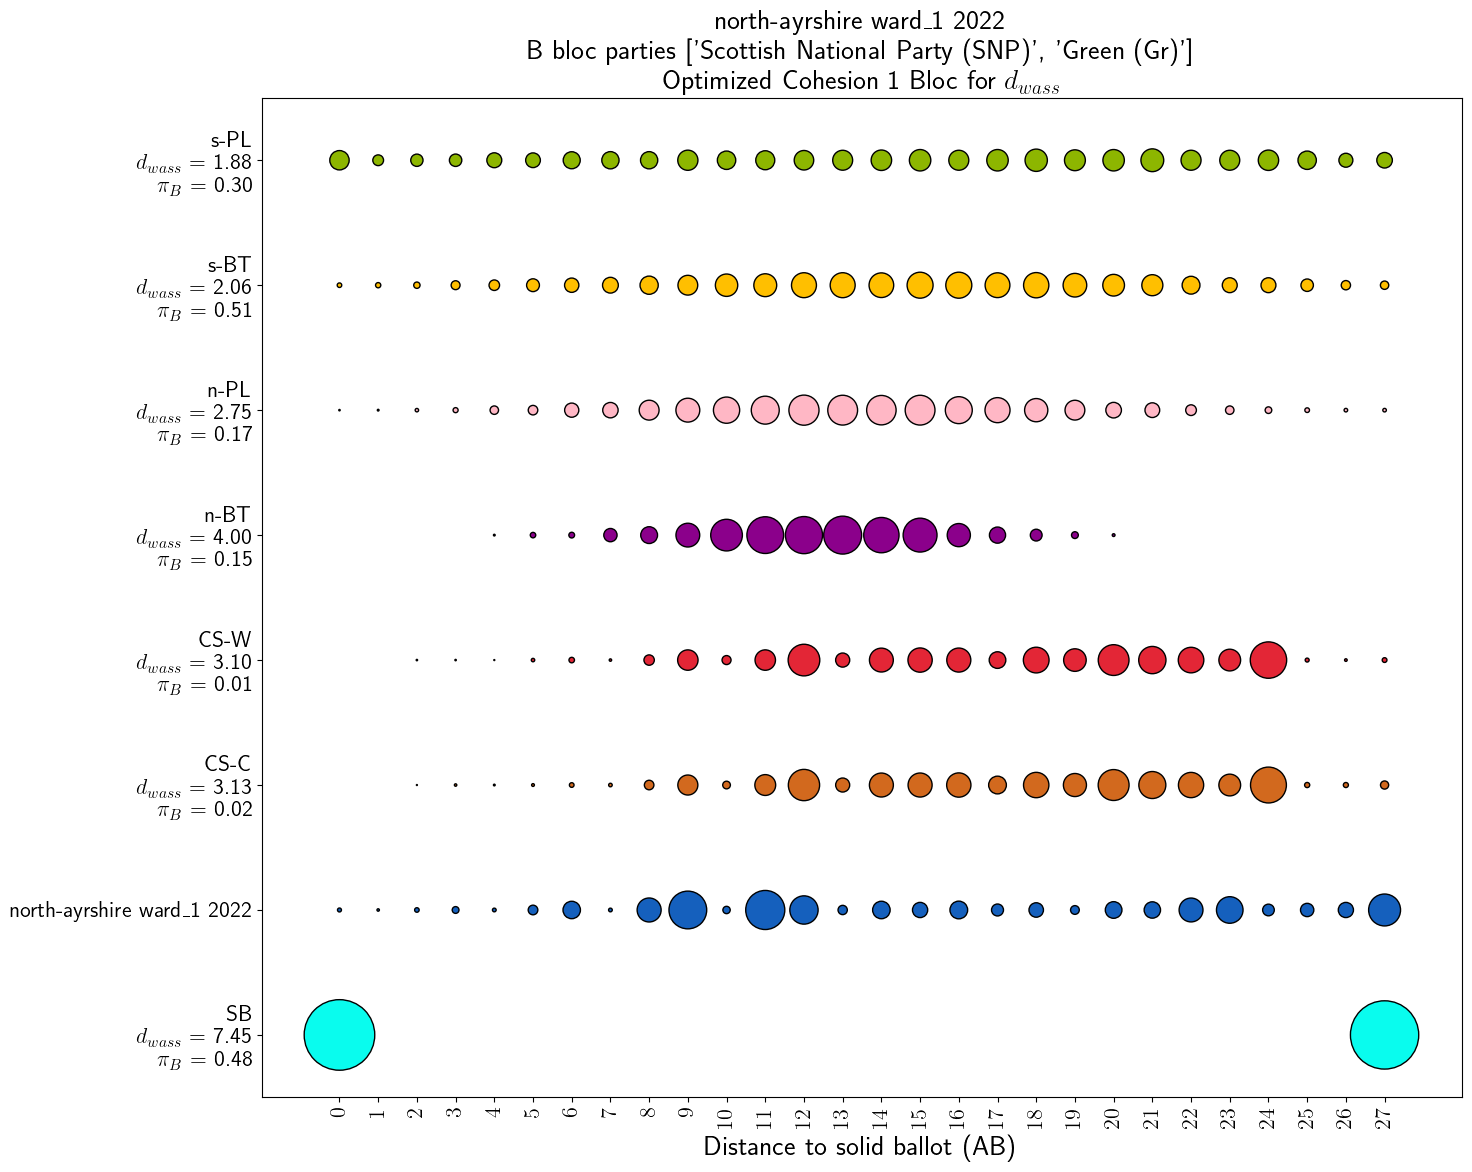

<Figure size 640x480 with 0 Axes>

In [13]:
bloc_order = "AB"
stat = "WD" # wasserstein distance

for key, file_name in file_names.items():
    city, year, ward = key

    # too many cands for IC, IAC
    if city in ["glasgow", "north-ayrshire"]:
        temp_old_models = ["SB"]
        height = 12
    else: 
        temp_old_models = ["SB", "IC", "IAC"]
        height = 14

    fig, ax = plt.subplots(figsize = (15, height))
    
    ward_label = f"{city} ward_{ward} {year}"

    scottish_profile, num_seats, cand_list, cand_to_party, ward = load_scottish(file_name)
    cand_to_bloc = {c:"B" if cand_to_party[c] in b_bloc_parties 
                else "A" for c in cand_list}
    
    # count the number of candidates in each bloc
    bloc_to_cand_num = {"A": len([c for c, bloc in cand_to_bloc.items() if bloc == "A"]),
                        "B": len([c for c, bloc in cand_to_bloc.items() if bloc == "B"])}
    
    scot_data = dist_profile_to_solid(scottish_profile, cand_to_bloc, bloc_order)



    
    old_opt_data = []
    new_opt_data = []
    opt_wds = {}
    opt_cohesion = {}

    
    model_list = temp_old_models+new_models
    for model_str in model_list:
        with open(f"distance_data/1_bloc/distance_to_solid_{ward_label}_one_bloc_optimized_{stat}_{model_str}_bloc_order_{bloc_order}_b_bloc_parties_{b_bloc_parties}.pickle", "rb") as f:
            min_pi_b, opt_distances = pickle.load(f)
        
        if model_str in temp_old_models:
            old_opt_data.append(opt_distances)
        else:
            new_opt_data.append(opt_distances)
        opt_wds[model_str] = wasserstein_distance(scot_data, opt_distances)
        opt_cohesion[model_str] = round(min_pi_b,2) if isinstance(min_pi_b, float) else min_pi_b

    title = f"{ward_label}\nB bloc parties {b_bloc_parties}\n"

    colors = [model_to_color[m] for m in temp_old_models]+[scottish_color]+[model_to_color[m] for m in new_models]
    pi_b_tex = r"$\pi_B$"
    d_wass_tex = r"$d_{wass}$"
    

    labels = [f"{m}\n {d_wass_tex} = {opt_wds[m]:.2f}\n{pi_b_tex} = {opt_cohesion[m]}" for m in temp_old_models] +[ward_label] + \
        [f"{m}\n {d_wass_tex} = {opt_wds[m]:.2f}\n{pi_b_tex} = {opt_cohesion[m]:.2f}" for m in new_models]
    bubble_plot_integer(ax, old_opt_data+[scot_data] + new_opt_data, 
                            labels, 
                            colors, 
                            title+f"Optimized Cohesion 1 Bloc for {d_wass_tex}",
                            bloc_order,
                            size = 20000,)
                            

    plt.tight_layout()
    plt.show()
    # plt.savefig(f"figures/bubble_plots/{ward_label}_swap_distance_bubble_plots.pdf")
    plt.clf()
    




# scot hist

In [10]:
for key, file_name in file_names.items():
    city, year, ward = key
    label = f"{city.capitalize()} Ward {ward} {year}"
    print(label)
    scottish_profile, num_seats, cand_list, cand_to_party, ward = load_scottish(file_name)
    cand_to_bloc = {c:"B" if cand_to_party[c] in b_bloc_parties 
                else "A" for c in cand_list}
    
    # count the number of candidates in each bloc
    bloc_to_cand_num = {"A": len([c for c, bloc in cand_to_bloc.items() if bloc == "A"]),
                        "B": len([c for c, bloc in cand_to_bloc.items() if bloc == "B"])}
    
    bloc_to_cand_num = {"A": len([c for c, bloc in cand_to_bloc.items() if bloc == "A"]),
                        "B": len([c for c, bloc in cand_to_bloc.items() if bloc == "B"])}
    
    
    dist_to_solid = dist_profile_to_solid(scottish_profile, cand_to_bloc, bloc_to_cand_num)

    fig,ax = plt.subplots(figsize=(8,6))
    bin_min = 0
    bin_max = max(dist_to_solid)
    bins = np.arange(bin_min-.5, bin_max+1.5, 1)
    ax.hist(dist_to_solid, bins = bins, label = label , density= True, alpha = 1, color = scottish_color)
    ax.set_xticks(range(int(bin_max)+1))
    ax.tick_params(axis='x', labelrotation=90)
    # ax.legend()
    ax.set_xlabel("Distance to solid (A over B)")
    ax.set_ylabel("Density")
    ax.set_title(f"{label}")

    # plt.show()
    plt.tight_layout()
    plt.savefig(f"figures/{label}_distance_to_solid_hist.pdf")
    plt.clf()
    



Fife Ward 21 2022
Aberdeen Ward 12 2017
Aberdeen Ward 12 2022
Angus Ward 8 2012
Falkirk Ward 6 2017
Clackmannanshire Ward 2 2012
Renfrewshire Ward 1 2017
Glasgow Ward 16 2012
North-ayrshire Ward 1 2022


<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

# Highlighted elections

aberdeen ward_12 2017


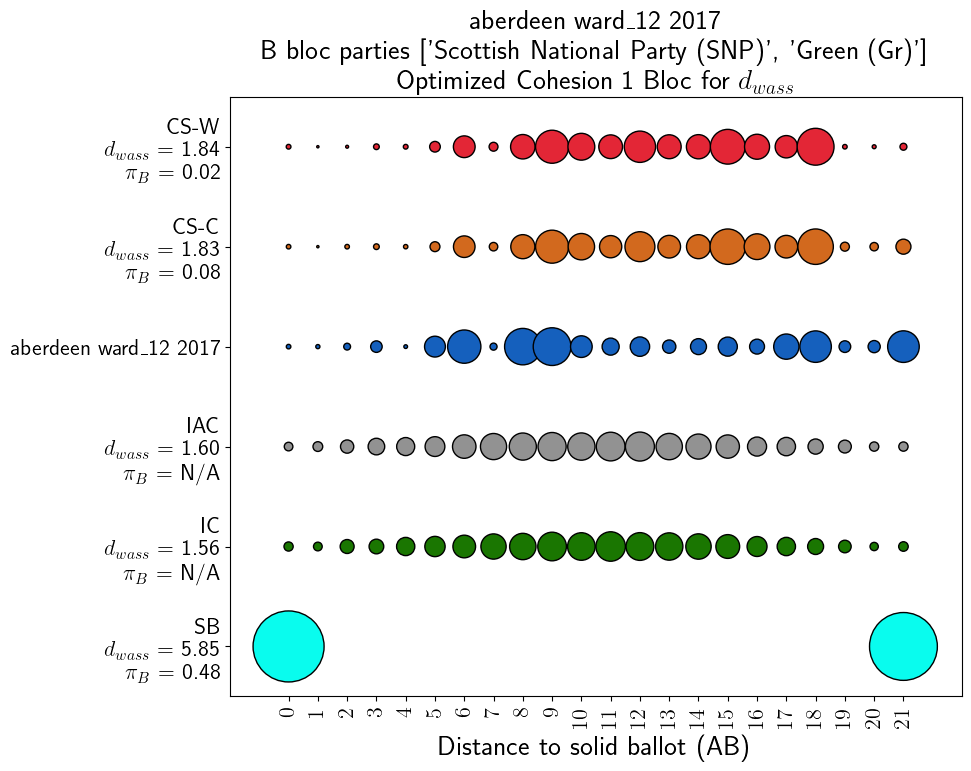

<Figure size 640x480 with 0 Axes>

In [11]:
#aberdeen 12 2017 both cs
bloc_order = "AB"
stat = "WD"

key = ("aberdeen", 2017, 12)
file_name = file_names[key]
fig, ax = plt.subplots(figsize = (10, 8))
city, year, ward = key
ward_label = f"{city} ward_{ward} {year}"
print(ward_label)

scottish_profile, num_seats, cand_list, cand_to_party, ward = load_scottish(file_name)
cand_to_bloc = {c:"B" if cand_to_party[c] in b_bloc_parties 
            else "A" for c in cand_list}

# count the number of candidates in each bloc
bloc_to_cand_num = {"A": len([c for c, bloc in cand_to_bloc.items() if bloc == "A"]),
                    "B": len([c for c, bloc in cand_to_bloc.items() if bloc == "B"])}

scot_data = dist_profile_to_solid(scottish_profile, cand_to_bloc, bloc_order)
data = {}

# draft_2/distance_data/1_bloc/distance_to_solid_renfrewshire ward_1 2017_one_bloc_optimized_WD_solid_bloc_order_AB_b_bloc_parties_['Scottish National Party (SNP)', 'Green (Gr)'].pickle
with open(f"distance_data/1_bloc/distance_to_solid_{ward_label}_one_bloc_optimized_{stat}_solid_bloc_order_{bloc_order}_b_bloc_parties_{b_bloc_parties}.pickle", "rb") as f:
    min_solid_pi_b, solid_data = pickle.load(f)
solid_wass = wasserstein_distance(solid_data, scot_data)

old_opt_data = []
new_opt_data = []
opt_wds = {}
opt_cohesion = {}

models = ["CS-C", "CS-W"]
for model_str in old_models + models:
    with open(f"distance_data/1_bloc/distance_to_solid_{ward_label}_one_bloc_optimized_{stat}_{model_str}_bloc_order_{bloc_order}_b_bloc_parties_{b_bloc_parties}.pickle", "rb") as f:
        min_pi_b, opt_distances = pickle.load(f)
    
    if model_str in old_models:
        old_opt_data.append(opt_distances)
    else:
        new_opt_data.append(opt_distances)
    opt_wds[model_str] = wasserstein_distance(scot_data, opt_distances)
    opt_cohesion[model_str] = round(min_pi_b,2) if isinstance(min_pi_b, float) else min_pi_b

title = f"{ward_label}\nB bloc parties {b_bloc_parties}\n"
# print([x[0] for x in sorted(opt_wds.items(), key= lambda x: x[1])])
colors = [model_to_color[m] for m in old_models]+[scottish_color]+[model_to_color[m] for m in models]
pi_b_tex = r"$\pi_B$"
d_wass_tex = r"$d_{wass}$"



labels =  [f"{m}\n {d_wass_tex} = {opt_wds[m]:.2f}\n{pi_b_tex} = {opt_cohesion[m]}" for m in old_models]+[ward_label] + \
    [f"{m}\n {d_wass_tex} = {opt_wds[m]:.2f}\n{pi_b_tex} = {opt_cohesion[m]:.2f}" for m in models]
bubble_plot_integer(ax, old_opt_data+[scot_data] + new_opt_data, 
                        labels, 
                        colors, 
                        title+f"Optimized Cohesion 1 Bloc for {d_wass_tex}",
                        bloc_order,
                        size = 20000,)
                        



plt.tight_layout()
plt.show()
# plt.savefig(f"figures/HIGHLIGHT_{ward_label}_swap_distance_bubble_plots.pdf")
plt.clf()





falkirk ward_6 2017


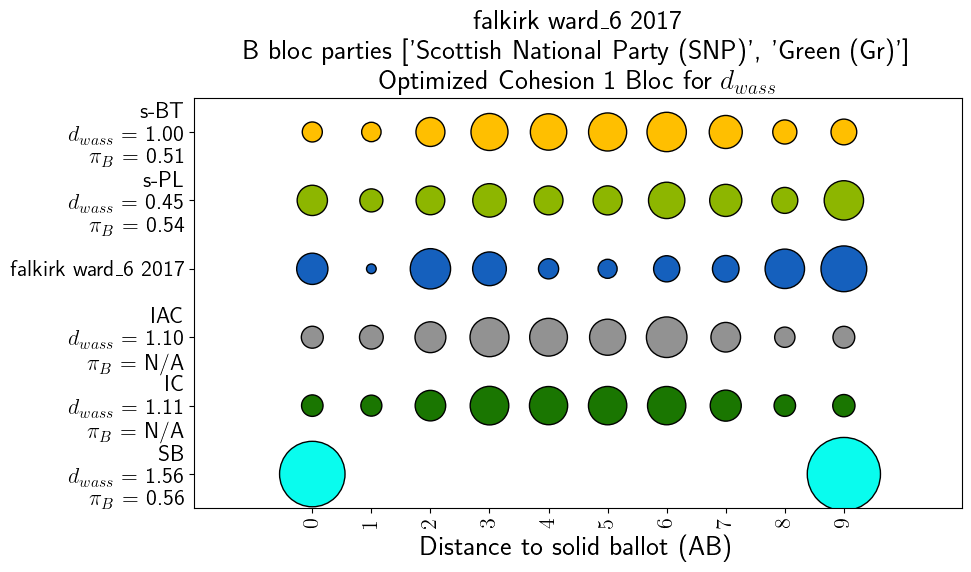

<Figure size 640x480 with 0 Axes>

In [12]:
# falkrirk 6 2017 both slate, solid
bloc_order = "AB"
stat = "WD"

key = ("falkirk", 2017, 6)
file_name = file_names[key]
fig, ax = plt.subplots(figsize = (10, 6))
city, year, ward = key
ward_label = f"{city} ward_{ward} {year}"
print(ward_label)

scottish_profile, num_seats, cand_list, cand_to_party, ward = load_scottish(file_name)
cand_to_bloc = {c:"B" if cand_to_party[c] in b_bloc_parties 
            else "A" for c in cand_list}

# count the number of candidates in each bloc
bloc_to_cand_num = {"A": len([c for c, bloc in cand_to_bloc.items() if bloc == "A"]),
                    "B": len([c for c, bloc in cand_to_bloc.items() if bloc == "B"])}

scot_data = dist_profile_to_solid(scottish_profile, cand_to_bloc, bloc_order)
data = {}

# draft_2/distance_data/1_bloc/distance_to_solid_renfrewshire ward_1 2017_one_bloc_optimized_WD_solid_bloc_order_AB_b_bloc_parties_['Scottish National Party (SNP)', 'Green (Gr)'].pickle
with open(f"distance_data/1_bloc/distance_to_solid_{ward_label}_one_bloc_optimized_{stat}_solid_bloc_order_{bloc_order}_b_bloc_parties_{b_bloc_parties}.pickle", "rb") as f:
    min_solid_pi_b, solid_data = pickle.load(f)
solid_wass = wasserstein_distance(solid_data, scot_data)

old_opt_data = []
new_opt_data = []
opt_wds = {}
opt_cohesion = {}

models = ["s-PL", "s-BT"]
for model_str in old_models + models:
    with open(f"distance_data/1_bloc/distance_to_solid_{ward_label}_one_bloc_optimized_{stat}_{model_str}_bloc_order_{bloc_order}_b_bloc_parties_{b_bloc_parties}.pickle", "rb") as f:
        min_pi_b, opt_distances = pickle.load(f)
    
    if model_str in old_models:
        old_opt_data.append(opt_distances)
    else:
        new_opt_data.append(opt_distances)
    opt_wds[model_str] = wasserstein_distance(scot_data, opt_distances)
    opt_cohesion[model_str] = round(min_pi_b,2) if isinstance(min_pi_b, float) else min_pi_b

title = f"{ward_label}\nB bloc parties {b_bloc_parties}\n"
# print([x[0] for x in sorted(opt_wds.items(), key= lambda x: x[1])])
colors = [model_to_color[m] for m in old_models]+[scottish_color]+[model_to_color[m] for m in models]
pi_b_tex = r"$\pi_B$"
d_wass_tex = r"$d_{wass}$"



labels =  [f"{m}\n {d_wass_tex} = {opt_wds[m]:.2f}\n{pi_b_tex} = {opt_cohesion[m]}" for m in old_models]+[ward_label] + \
    [f"{m}\n {d_wass_tex} = {opt_wds[m]:.2f}\n{pi_b_tex} = {opt_cohesion[m]:.2f}" for m in models]
bubble_plot_integer(ax, old_opt_data+[scot_data] + new_opt_data, 
                        labels, 
                        colors, 
                        title+f"Optimized Cohesion 1 Bloc for {d_wass_tex}",
                        bloc_order,
                        size = 20000,)
                        



plt.tight_layout()
plt.show()
# plt.savefig(f"figures/HIGHLIGHT_{ward_label}_swap_distance_bubble_plots.pdf")
plt.clf()





Table 1: stv prop

In [61]:
bloc_order = "AB"
stat = "WD"
# to do, make 1 row 3 column area plots
# each row is FPV, borda, opt
# each col is model type
for key, file_name in file_names.items():
    city, year, ward = key
    ward_label = f"{city} ward_{ward} {year}"
    print(ward_label)
    m_parameters = estimate_1_bloc_parameters(file_name, b_bloc_parties)

    scottish_profile, num_seats, cand_list, cand_to_party, ward = load_scottish(file_name)
    cand_to_bloc = {c:"B" if cand_to_party[c] in b_bloc_parties 
                else "A" for c in cand_list}
    
    # count the number of candidates in each bloc
    bloc_to_cand_num = {"A": len([c for c, bloc in cand_to_bloc.items() if bloc == "A"]),
                        "B": len([c for c, bloc in cand_to_bloc.items() if bloc == "B"])}
    
    # print(bloc_to_cand_num)
    print("FPV", round(m_parameters["bloc_first"]["B"],2), round(m_parameters["bloc_first"]["B"],2)*num_seats)
    print("BORDA", round(m_parameters["borda_share"]["B"],2), round(m_parameters["borda_share"]["B"],2)*num_seats)
    # record number of B winners
    election  = STV(profile = scottish_profile, transfer=fractional_transfer, seats = num_seats)
    results = election.run_election()
    winners= [c for s in results.winners() for c in s]
    print(winners)
    print([cand_to_party[c] for c in winners])
    num_B_winners = len([c for c in winners if cand_to_bloc[c] == "B"])

    print("Seats won by B bloc", num_B_winners)
    print()
    print("\n-----------\n")
    




fife ward_21 2022
FPV 0.45 1.8
BORDA 0.45 1.8
['David Alexander', 'Colin Davidson', 'Alistair Belford Suttie', 'Eugene Mcdonald Clarke']
['Scottish National Party (SNP)', 'Labour (Lab)', 'Scottish National Party (SNP)', 'Liberal Democrat (LD)']
Seats won by B bloc 2


-----------

aberdeen ward_12 2017
FPV 0.36 1.44
BORDA 0.39 1.56
['Alan Donnelly', 'Yvonne Allan', 'Christian Guy Allard', 'Catriona Mackenzie']
['Conservative and Unionist Party (Con)', 'Labour (Lab)', 'Scottish National Party (SNP)', 'Scottish National Party (SNP)']
Seats won by B bloc 2


-----------

aberdeen ward_12 2022
FPV 0.48 1.92
BORDA 0.48 1.92
['Christian Allard', 'Michael Kusznir', 'Simon Peter Watson', 'Lee Fairfull']
['Scottish National Party (SNP)', 'Conservative and Unionist Party (Con)', 'Labour (Lab)', 'Scottish National Party (SNP)']
Seats won by B bloc 2


-----------

angus ward_8 2012
FPV 0.39 1.56
BORDA 0.4 1.6
['Mark Salmond', 'Bill Duff', 'Paul Michael Valentine', 'David May']
['Independent (Ind)